## Tutorial: Selecting a Galaxy Sample from IllustrisTNG

This tutorial demonstrates how to load group catalog of a specific snapshot from the TNG50-1 simulation using the `illustris_python` API (https://github.com/illustristng/illustris_python), calculate physical properties, and filter galaxies based on mass and SFR. For this example, we will select a sample of massive, quiescent galaxies at z~1.5 (snapshot number=40). 

In [1]:
import os, sys
import numpy as np 
import matplotlib.pyplot as plt 
import illustris_python as il

### Load Group Catalog Data

We define the path to the simulation data and load the subhalo (galaxy) catalog for a specific snapshot (redshift). We point `illustris_python` at the simulation output directory and load
**all** subhalo fields for the chosen snapshot.

> **Tip:** Change `snap_number` to select a different redshift.
> Use the [TNG snapshot table](https://www.tng-project.org/data/docs/specifications/#sec1a)
> to find the snapshot index that corresponds to your target redshift.
> Download group catalogs from [this link](https://www.tng-project.org/data/downloads/TNG50-1/) and follow instruction [at this link](https://www.tng-project.org/data/docs/scripts/) for instructions on storing the data.  

In [2]:
# Path to the TNG50-1 simulation output on the local disk
basePath = '/Volumes/disk4tb/data/TNG/TNG50-1/output'

# Snapshot number 40 corresponds to a specific redshift (e.g., z ≈ 1.5)
snap_number = 40

# Load the subhalo (galaxy) catalog from the groupcat
subhalos = il.groupcat.loadSubhalos(basePath, snap_number)

### Unit Conversions and Property Extraction

In this example, we pull three key fields from the catalog and convert them to physical units. The Hubble parameter **h = 0.6774** converts the raw simulation mass unit (10^10 M_sun / h) to solar masses. More fields from the catalog can be seen at [this link](https://www.tng-project.org/data/docs/specifications/#sec2b).

In [ ]:
# Hubble parameter for TNG simulations
h = 0.6774

# Extract stellar mass within twice the stellar half-mass radius (index 4 = stars)
# Convert from 1e10 M_sun/h to M_sun
mstar_2re = subhalos['SubhaloMassInRadType'][:,4] * 1e+10 / h 

# Extract the Star Formation Rate (SFR) and the half-mass radius
sfr_2re = subhalos['SubhaloSFRinRad']

# get half stellar mass radius and convert into kpc
from galsyn.simutils_tng import get_snap_z
api_key = "your_api_key"
snap_z = get_snap_z(snap_number, sim='TNG50-1', api_key=api_key)
snap_a = 1.0/(1.0 + snap_z)
halfmass_rad = subhalos['SubhaloHalfmassRadType'][:,4] * snap_a / h  # in kpc

# Print the total number of subhalos found in this snapshot
snap_ngals = len(mstar_2re)
print(f'Number of galaxies in the snapshot: {snap_ngals}')

Number of galaxies in the snapshot: 7239049


### Visualise All Subhalos — Star-Forming Main Sequence

We plot **log(SFR)** vs. **log(M_star)** for every subhalo in the snapshot.
This diagnostic plot reveals the full galaxy population, including the
star-forming main sequence and the cloud of passive/quenched objects
below it.

> **Note:** Subhalos with SFR = 0 produce a `divide by zero` warning
> when `log10(0)` is evaluated. Those points map to minus infinity and
> are not rendered by matplotlib as expected.

/var/folders/hv/lc17r4z1771706j1587rhsph0000gn/T/ipykernel_98021/2983625982.py:4: RuntimeWarning: divide by zero encountered in log10
  ax.scatter(np.log10(mstar_2re), np.log10(sfr_2re),


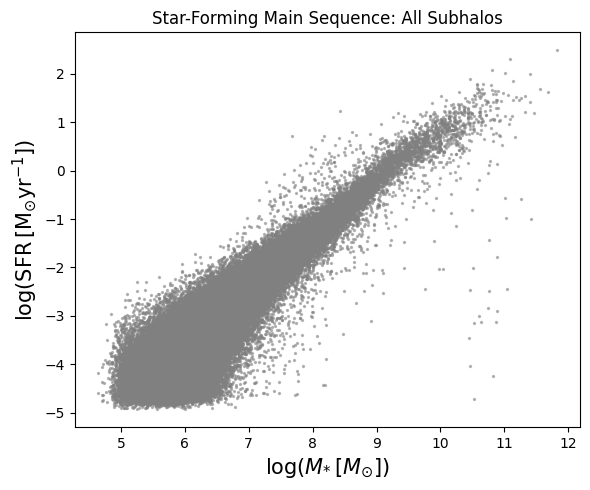

In [10]:
fig, ax = plt.subplots(figsize=(6, 5))

# All subhalos plotted in grey with low opacity
ax.scatter(np.log10(mstar_2re), np.log10(sfr_2re),
           s=2, color='gray', alpha=0.5)

ax.set_xlabel(r'$\log(M_{*}\,[M_{\odot}])$', fontsize=15)
ax.set_ylabel(r'$\log(\rm{SFR}\,[M_{\odot}\rm{yr}^{-1}])$', fontsize=15)
ax.set_title('Star-Forming Main Sequence: All Subhalos')

plt.tight_layout()
plt.show()

### Apply Selection Cuts — Massive Passive Galaxies

In this example, we select subhalos that are massive and passive (quiescent). The selected galaxies are then overplotted in **red** on the star-forming main sequence diagram.

/var/folders/hv/lc17r4z1771706j1587rhsph0000gn/T/ipykernel_98021/1400514443.py:3: RuntimeWarning: divide by zero encountered in log10
  (np.log10(mstar_2re) > 10.0) &                               # mass cut
/var/folders/hv/lc17r4z1771706j1587rhsph0000gn/T/ipykernel_98021/1400514443.py:4: RuntimeWarning: divide by zero encountered in log10
  (np.log10(sfr_2re) - np.log10(mstar_2re) < -10.0)           # sSFR cut
/var/folders/hv/lc17r4z1771706j1587rhsph0000gn/T/ipykernel_98021/1400514443.py:4: RuntimeWarning: invalid value encountered in subtract
  (np.log10(sfr_2re) - np.log10(mstar_2re) < -10.0)           # sSFR cut
/var/folders/hv/lc17r4z1771706j1587rhsph0000gn/T/ipykernel_98021/1400514443.py:15: RuntimeWarning: divide by zero encountered in log10
  ax.scatter(np.log10(mstar_2re), np.log10(sfr_2re),


Number of selected galaxies: 64


/var/folders/hv/lc17r4z1771706j1587rhsph0000gn/T/ipykernel_98021/1400514443.py:19: RuntimeWarning: divide by zero encountered in log10
  ax.scatter(np.log10(mstar_2re[idx_select]), np.log10(sfr_2re[idx_select]),
/var/folders/hv/lc17r4z1771706j1587rhsph0000gn/T/ipykernel_98021/1400514443.py:27: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/Users/abdurroufabdurrouf/anaconda3/envs/rsedfits1/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


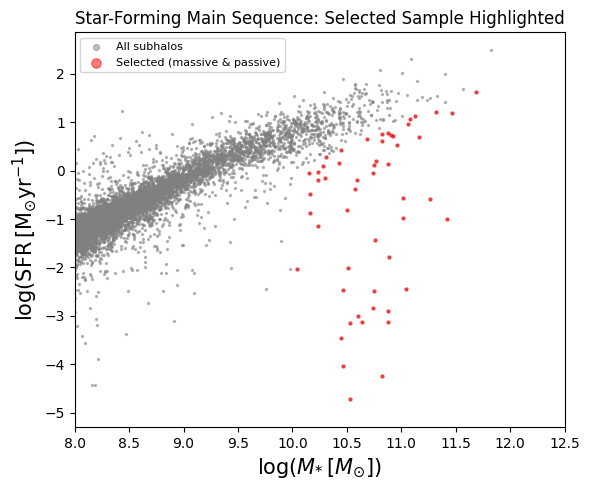

In [11]:
# Selection mask: massive (log M* > 10) AND passive (sSFR < 10^-10 / yr)
idx_select = np.where(
    (np.log10(mstar_2re) > 10.0) &                               # mass cut
    (np.log10(sfr_2re) - np.log10(mstar_2re) < -10.0)           # sSFR cut
)[0]

print('Number of selected galaxies: %d' % len(idx_select))

# --- Diagnostic plot ---
fig, ax = plt.subplots(figsize=(6, 5))

ax.set_xlim(8.0, 12.5)

# Background: all subhalos (grey)
ax.scatter(np.log10(mstar_2re), np.log10(sfr_2re),
           s=2, color='gray', alpha=0.5, label='All subhalos')

# Foreground: selected passive massive galaxies (red)
ax.scatter(np.log10(mstar_2re[idx_select]), np.log10(sfr_2re[idx_select]),
           s=5, color='red', alpha=0.5, label='Selected (massive & passive)')

ax.set_xlabel(r'$\log(M_{*}\,[M_{\odot}])$', fontsize=15)
ax.set_ylabel(r'$\log(\rm{SFR}\,[M_{\odot}\rm{yr}^{-1}])$', fontsize=15)
ax.set_title('Star-Forming Main Sequence: Selected Sample Highlighted')
ax.legend(markerscale=3, fontsize=8)

plt.tight_layout()
plt.show()

### Visualise the Selected Sample — Size-Mass Plane

We plot the stellar **half-mass radius** against **log(M_star)** for all
subhalos and highlight the selected passive sample in red.

/var/folders/hv/lc17r4z1771706j1587rhsph0000gn/T/ipykernel_98021/40565686.py:8: RuntimeWarning: divide by zero encountered in log10
  ax.scatter(np.log10(mstar_2re), halfmass_rad,
/var/folders/hv/lc17r4z1771706j1587rhsph0000gn/T/ipykernel_98021/40565686.py:20: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/Users/abdurroufabdurrouf/anaconda3/envs/rsedfits1/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


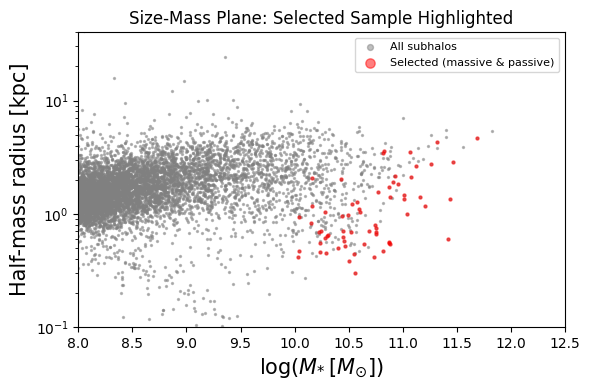

In [13]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.set_xlim(8.0, 12.5)
ax.set_ylim(0.1, 40.0)
ax.set_yscale('log')   # log y-axis to capture the full size dynamic range

# Background: all subhalos (grey)
ax.scatter(np.log10(mstar_2re), halfmass_rad,
           s=2, color='gray', alpha=0.5, label='All subhalos')

# Foreground: selected massive passive galaxies (red)
ax.scatter(np.log10(mstar_2re[idx_select]), halfmass_rad[idx_select],
           s=5, color='red', alpha=0.5, label='Selected (massive & passive)')

ax.set_xlabel(r'$\log(M_{*}\,[M_{\odot}])$', fontsize=15)
ax.set_ylabel('Half-mass radius [kpc]', fontsize=15)
ax.set_title('Size-Mass Plane: Selected Sample Highlighted')
ax.legend(markerscale=3, fontsize=8)

plt.tight_layout()
plt.show()

### List of selected galaxies

In [16]:
import pandas as pd

# Accumulate one record per selected galaxy
selected_galaxies = []
for idx in idx_select:
    # Use a descriptive variable name to avoid shadowing the built-in 'dict'
    entry = {
        'subhalo_id':   int(idx),                      # integer catalog row index
        'log_mass':     np.log10(mstar_2re[idx]),      # log10 stellar mass  [M_sun]
        'log_sfr':      np.log10(sfr_2re[idx]),        # log10 SFR  [M_sun/yr]  (-inf if SFR=0)
        'halfmass_rad': halfmass_rad[idx],             # stellar half-mass radius
    }
    selected_galaxies.append(entry)

# Convert the list of dicts to a Pandas DataFrame
df = pd.DataFrame(selected_galaxies)

print('Selected sample: %d galaxies' % len(df))
df

Selected sample: 64 galaxies


/var/folders/hv/lc17r4z1771706j1587rhsph0000gn/T/ipykernel_98021/966266657.py:10: RuntimeWarning: divide by zero encountered in log10
  'log_sfr':      np.log10(sfr_2re[idx]),        # log10 SFR  [M_sun/yr]  (-inf if SFR=0)


,subhalo_id,log_mass,log_sfr,halfmass_rad
0,2,10.742894,-0.048570,0.788962
1,4,10.604605,-2.995254,1.043410
2,10,10.563811,-inf,0.299611
3,13,10.158179,-0.865549,2.064334
4,21,10.028956,-inf,0.417079
...,...,...,...,...
59,267462,10.299517,-0.149725,0.640564
60,270786,10.236309,-0.198731,0.547575
61,307826,10.237652,-1.135051,0.460361
62,309865,10.152498,-0.054076,0.822568
